# IPL Match Analysis 2022

## Objective

Analyze IPL match data to discover trends in

- Winning teams
- Toss decisions
- Top scorers
- Best bowlers
- Venue performance

Import required libraries for data analysis and visualization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warning messages for cleaner output
warnings.filterwarnings("ignore")

Load IPL dataset into a pandas DataFrame and Display first 5 rows of the dataset

In [4]:
df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check number of rows and columns in dataset

In [9]:
print(f" Your Rows Are {df.shape[0]} and your Columns are {df.shape[1]}")
df.shape

 Your Rows Are 74 and your Columns are 20


(74, 20)

Check missing values in each column

In [10]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

- Basic Question

1. Which Team Won The Most Matches ?

Text(0.5, 0, ' No. Of Won')

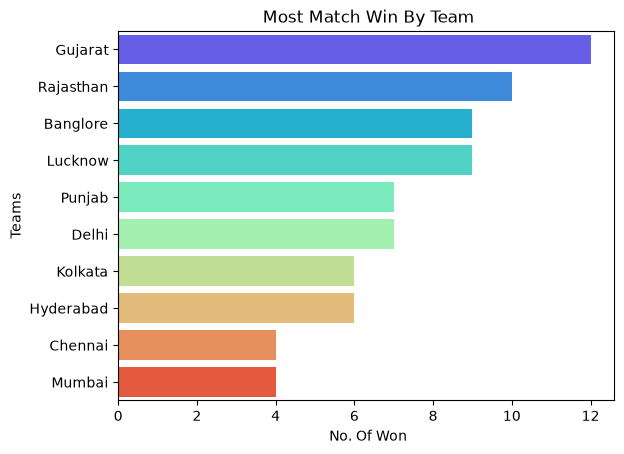

In [19]:
match_win = df["match_winner"].value_counts()
sns.barplot(y = match_win.index , x = match_win.values,palette="rainbow")
plt.title(" Most Match Win By Team")
plt.ylabel(" Teams ")
plt.xlabel(" No. Of Won")

2. Toss Decision Trends

Text(0.5, 1.0, ' Toss Decision Trends ')

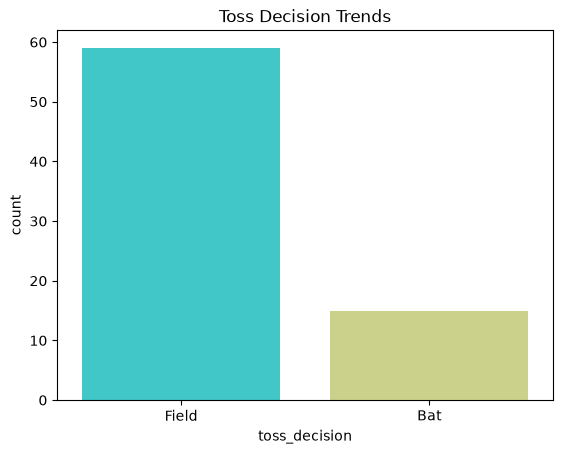

In [24]:
sns.countplot(x = df["toss_decision"],palette="rainbow")
plt.title(" Toss Decision Trends ")

3. Toss Winner VS Match Winner

In [ ]:
count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
percentage = ( count *100 ) / df.shape[0]
percentage.round(2)

np.float64(48.65)

4. How do Teams Win ? ( Runs vs Wickets )

Text(0.5, 1.0, ' Won by ')

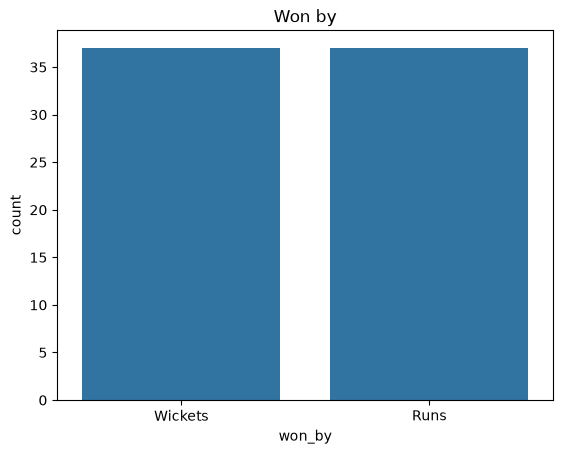

In [6]:
sns.countplot( x = df["won_by"])
plt.title(" Won by ")

## Key Player Performances

1. Most " Player Of The Awards "

Text(0.5, 1.0, ' Top 10 With Man Of The Match ')

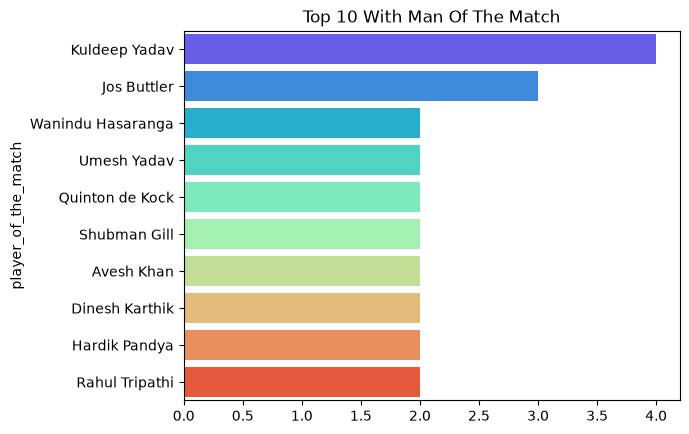

In [44]:
count = df["player_of_the_match"].value_counts().head(10)
sns.barplot( y = count.index, x = count.values,palette="rainbow")
plt.title(" Top 10 With Man Of The Match ")

2. Top Scores

<Axes: ylabel='top_scorer'>

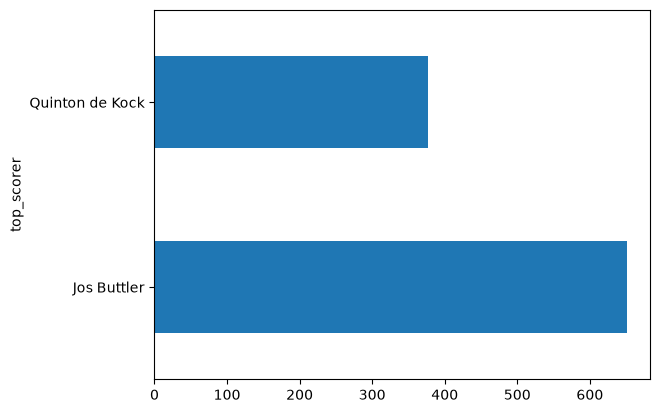

In [52]:
high = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)
high.plot(kind = "barh")

3. 10 Best Bowling Figures

<Axes: ylabel='best_bowling'>

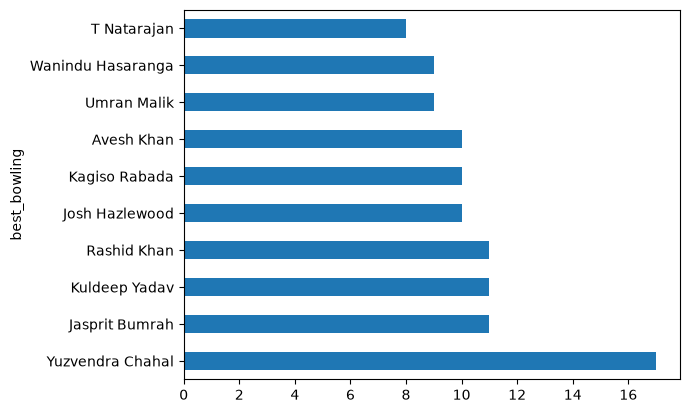

In [61]:
df["highest_wickets"] = df["best_bowling_figure"].apply(lambda x : x.split("--")[0])
df["highest_wickets"] = df["highest_wickets"].astype(int)
top_bowler = df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending = False).head(10)
top_bowler.plot(kind = "barh")

## Venue Analysis

1. Most Matches Played By Venue

<Axes: ylabel='venue'>

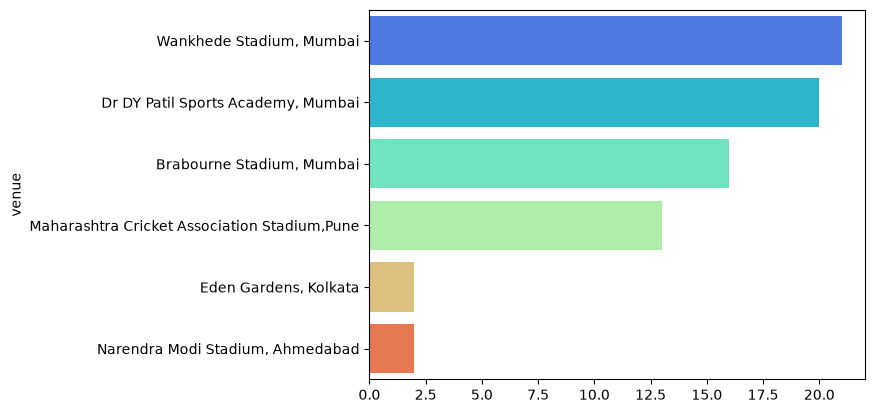

In [65]:
venue_count = df["venue"].value_counts()
sns.barplot( x = venue_count.values , y = venue_count.index,palette="rainbow")

### Custom Question & Insights

1. Who Won The Highest Margin By Runs?

In [69]:
df[df["won_by"] == "Runs"].sort_values(by = "margin" , ascending = False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


2. Which Player Had The Highest Individual Scores?

In [73]:
df[df["highscore"] == df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


3. Which Bowler Had The Best Bowling Figures?

In [79]:
df[df["highest_wickets"] == df["highest_wickets"].max()][["best_bowling","best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


## Conclusion

In this project, IPL 2022 match data was analyzed using Python, Pandas, Matplotlib, and Seaborn to uncover meaningful insights from the tournament. Through Exploratory Data Analysis (EDA), various factors such as team performance, toss decisions, player achievements, and venue statistics were examined.

The analysis revealed patterns that influence match outcomes and highlighted the importance of data-driven decision making in sports analytics. Visualizations made it easier to identify trends and compare performances across teams and players.

### This project strengthened my skills in:
- Python Programming
- Data Analysis
- Data Cleaning
- Data Visualization
- Exploratory Data Analysis (EDA)
- Working with Real-World Datasets

Overall, this project demonstrates how raw sports data can be transformed into actionable insights using data science techniques and serves as a foundation for future machine learning and predictive analytics projects.